In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the combined CSV
df = pd.read_csv("./results/combinedAnalysis.csv")
df.columns = df.columns.str.strip()

print(df.head())

   noise_level  lr_accuracy  rf_accuracy  lr_spearman_rank_correlation  \
0         0.00     0.868852     0.885246                      0.983516   
1         0.05     0.868852     0.901639                      0.989011   
2         0.10     0.868852     0.885246                      0.978022   
3         0.15     0.868852     0.868852                      0.961538   
4         0.20     0.868852     0.885246                      0.868132   

   rf_spearman_rank_correlation  
0                      1.000000  
1                      0.939560  
2                      0.945055  
3                      0.939560  
4                      0.939560  


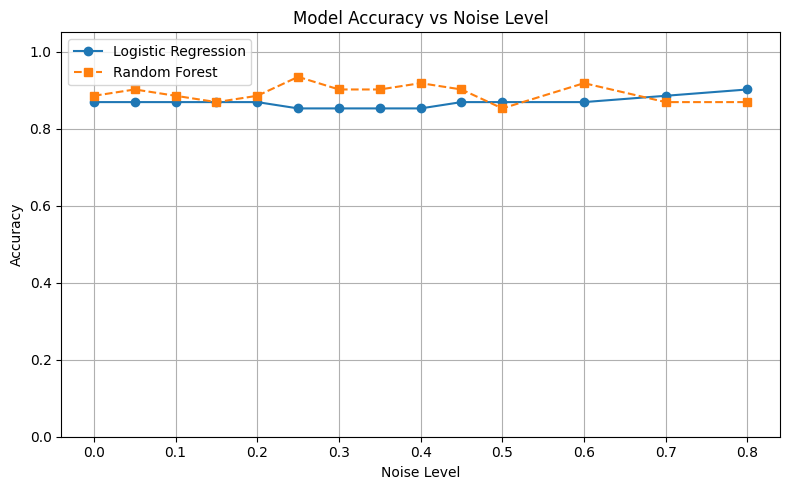

In [14]:
plt.figure(figsize=(8,5))

# Logistic Regression
plt.plot(
    df["noise_level"], 
    df["lr_accuracy"], 
    marker='o', 
    linestyle='-', 
    label='Logistic Regression'
)

# Random Forest
plt.plot(
    df["noise_level"], 
    df["rf_accuracy"], 
    marker='s', 
    linestyle='--', 
    label='Random Forest'
)

plt.xlabel("Noise Level")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

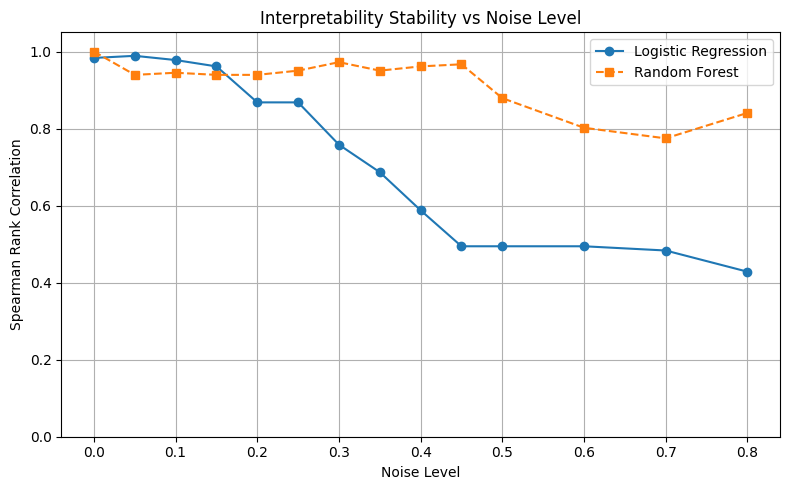

In [15]:
plt.figure(figsize=(8,5))

# Logistic Regression
plt.plot(
    df["noise_level"], 
    df["lr_spearman_rank_correlation"], 
    marker='o', 
    linestyle='-', 
    label='Logistic Regression'
)

# Random Forest
plt.plot(
    df["noise_level"], 
    df["rf_spearman_rank_correlation"], 
    marker='s', 
    linestyle='--', 
    label='Random Forest'
)

plt.xlabel("Noise Level")
plt.ylabel("Spearman Rank Correlation")
plt.title("Interpretability Stability vs Noise Level")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

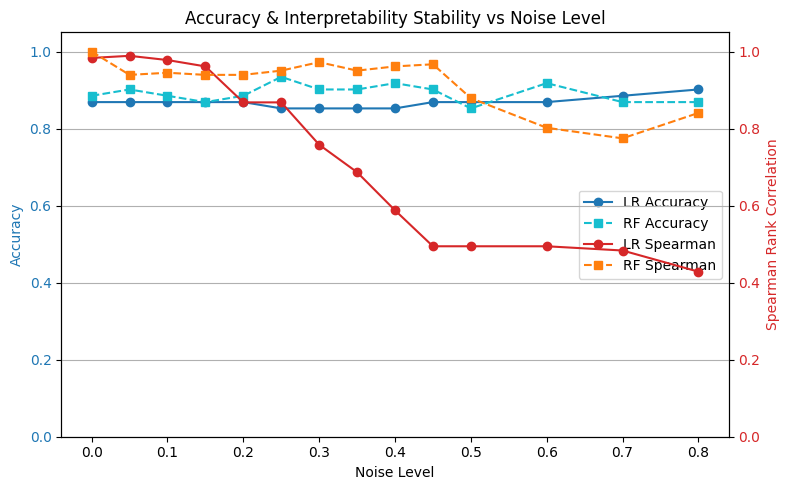

In [16]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis → Accuracy
ax1.set_xlabel("Noise Level")
ax1.set_ylabel("Accuracy", color="tab:blue")
ax1.plot(df["noise_level"], df["lr_accuracy"], 'o-', color="tab:blue", label="LR Accuracy")
ax1.plot(df["noise_level"], df["rf_accuracy"], 's--', color="tab:cyan", label="RF Accuracy")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_ylim(0,1.05)

# Right axis → Spearman
ax2 = ax1.twinx()
ax2.set_ylabel("Spearman Rank Correlation", color="tab:red")
ax2.plot(df["noise_level"], df["lr_spearman_rank_correlation"], 'o-', color="tab:red", label="LR Spearman")
ax2.plot(df["noise_level"], df["rf_spearman_rank_correlation"], 's--', color="tab:orange", label="RF Spearman")
ax2.tick_params(axis='y', labelcolor="tab:red")
ax2.set_ylim(0,1.05)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.title("Accuracy & Interpretability Stability vs Noise Level")
plt.grid(True)
plt.tight_layout()
plt.show()